In [1]:
import pandas as pd

#Loading the monthly transformed dataframe into the notebook
monthly_complete = pd.read_csv("monthly_data.csv")

print(monthly_complete)

            Date           City  Year of Occurrence  Month of Occurrence  \
0     2020-01-01           Agra                2020                    1   
1     2020-02-01           Agra                2020                    2   
2     2020-03-01           Agra                2020                    3   
3     2020-04-01           Agra                2020                    4   
4     2020-05-01           Agra                2020                    5   
...          ...            ...                 ...                  ...   
1590  2024-03-01  Visakhapatnam                2024                    3   
1591  2024-04-01  Visakhapatnam                2024                    4   
1592  2024-05-01  Visakhapatnam                2024                    5   
1593  2024-06-01  Visakhapatnam                2024                    6   
1594  2024-07-01  Visakhapatnam                2024                    7   

      Crime_Count  
0              11  
1               7  
2              19  
3      

In [2]:
monthly_complete.groupby("Month of Occurrence")["Crime_Count"].sum().sort_values(ascending = False)

Month of Occurrence
1     3720
3     3720
5     3720
7     3704
6     3600
4     3600
2     3408
8     2976
10    2976
12    2976
9     2880
11    2880
Name: Crime_Count, dtype: int64

In [3]:
#Calculate the rolling average for 3 months grouping by city

monthly_complete["MA3"] = (
    monthly_complete
    .groupby("City")["Crime_Count"]
    .rolling(3)
    .mean()
    .reset_index(level = 0, drop=True)
)
monthly_complete["MA3"]

0             NaN
1             NaN
2       12.333333
3       11.666667
4       16.000000
          ...    
1590    14.666667
1591    13.333333
1592    16.333333
1593    15.666667
1594    18.666667
Name: MA3, Length: 1595, dtype: float64

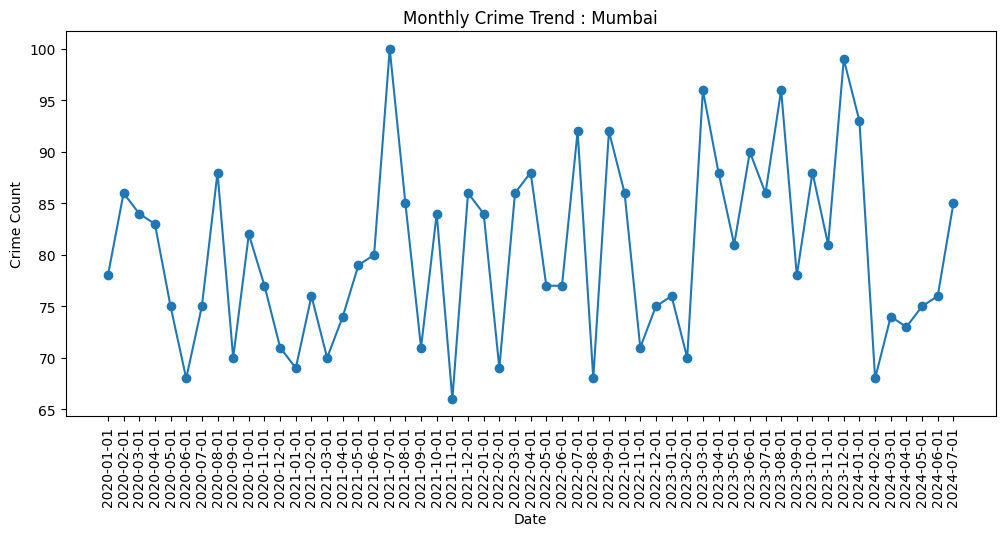

In [14]:
"""
We can observe that the monthly crime trend indicates a wildly fluctuating pattern
with spikes upwards in july 2021 and december 2023
"""

import matplotlib.pyplot as plt

city = "Mumbai"

city_df = monthly_complete[monthly_complete['City'] == city]

plt.figure(figsize=(12,5))
plt.plot(city_df['Date'], city_df['Crime_Count'], marker = "o")
plt.title(f"Monthly Crime Trend : {city}")
plt.xlabel("Date")
plt.ylabel("Crime Count")
plt.xticks(rotation = 90)
plt.show()



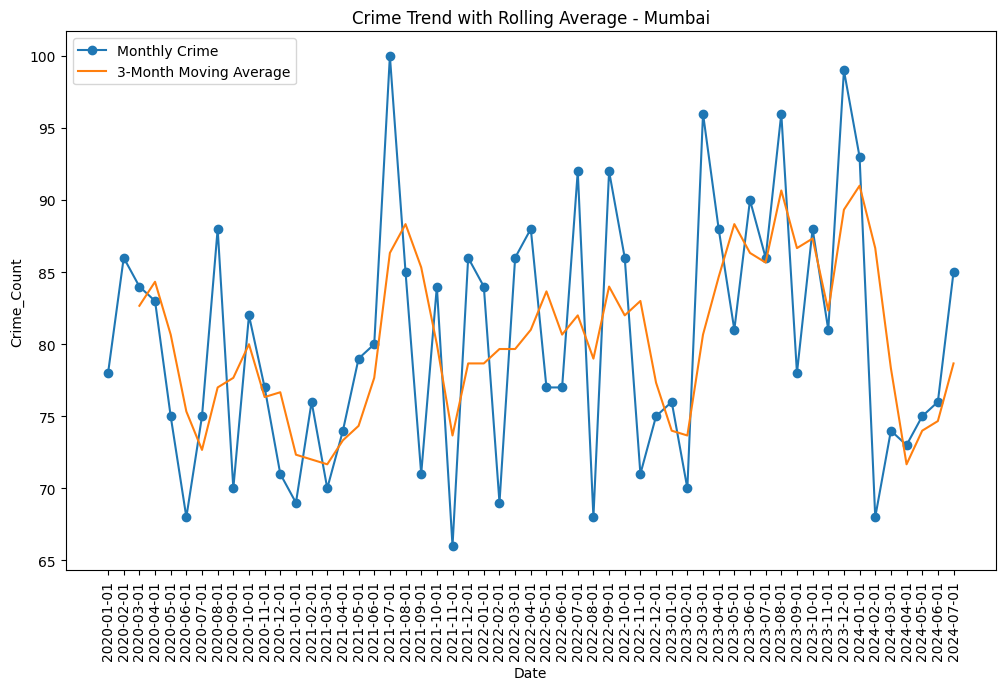

In [24]:
#Rolling averages reveal the underlying trend more clearly by reducing short-term noise

plt.figure(figsize=(12, 7))
plt.plot(city_df["Date"], city_df["Crime_Count"], label = "Monthly Crime", marker = "o")
plt.plot(city_df["Date"], city_df["MA3"], label = "3-Month Moving Average")
plt.title(f"Crime Trend with Rolling Average - {city}")
plt.xlabel("Date")
plt.ylabel("Crime_Count")
plt.xticks(rotation = 90)
plt.legend(["Monthly Crime", "3-Month Moving Average"])
plt.show()

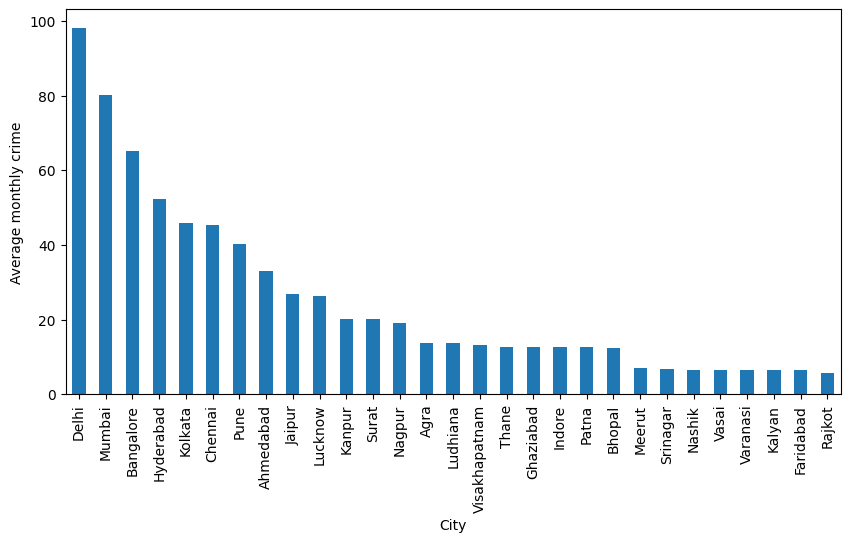

'\nThe average seems to be pretty stable and flat for most cities \n'

In [27]:
#Average monthly crime by city

city_avg = (
    monthly_complete
    .groupby("City")["Crime_Count"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
city_avg.plot(kind = "bar")
#plt.title("Average monthly crime by city")
plt.xlabel("City")
plt.ylabel("Average monthly crime")
plt.show()

"""
The average seems to be pretty stable and flat for most cities 
"""

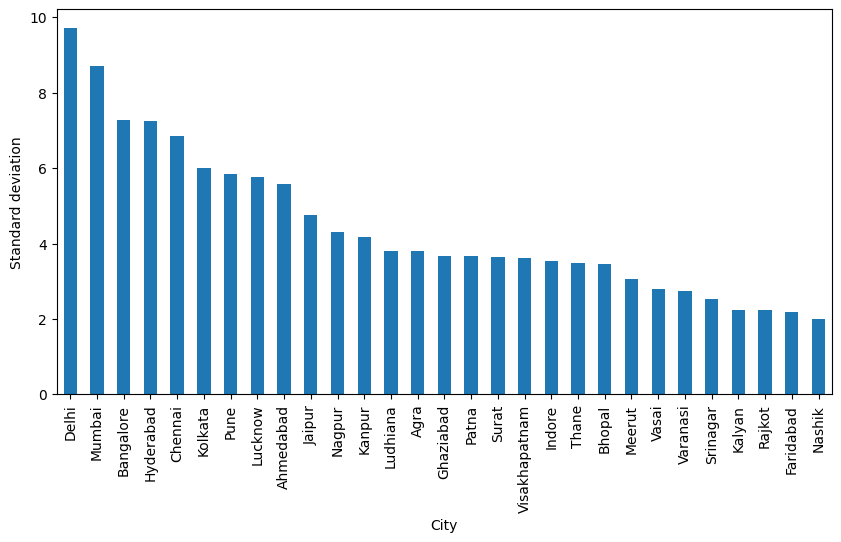

City
Delhi            9.722237
Mumbai           8.706010
Bangalore        7.290185
Hyderabad        7.260984
Chennai          6.842283
Kolkata          6.017539
Pune             5.842662
Lucknow          5.763405
Ahmedabad        5.567643
Jaipur           4.763568
Nagpur           4.317999
Kanpur           4.188569
Ludhiana         3.804304
Agra             3.798990
Ghaziabad        3.663635
Patna            3.663451
Surat            3.633180
Visakhapatnam    3.620741
Indore           3.541671
Thane            3.473517
Bhopal           3.457778
Meerut           3.067699
Vasai            2.786814
Varanasi         2.754244
Srinagar         2.532881
Kalyan           2.251075
Rajkot           2.228526
Faridabad        2.183809
Nashik           2.011248
Name: Crime_Count, dtype: float64


In [28]:
#Two cities can have the same crime count but very different stability 
#The lower the volatility, the higher the stability
"""
Crime volatility refers to the unpredictable, rapid, and 
significant fluctuations in the frequency or rate of criminal activity 
within a specific area or time period.
"""

city_volatility = (
    monthly_complete
    .groupby("City")["Crime_Count"]
    .std()
    .sort_values(ascending = False)
)

plt.figure(figsize=(10, 5))
city_volatility.plot(kind = "bar")
#plt.title("Crime volatility by City")
plt.xlabel("City")
plt.ylabel("Standard deviation")
plt.show()
print(city_volatility)

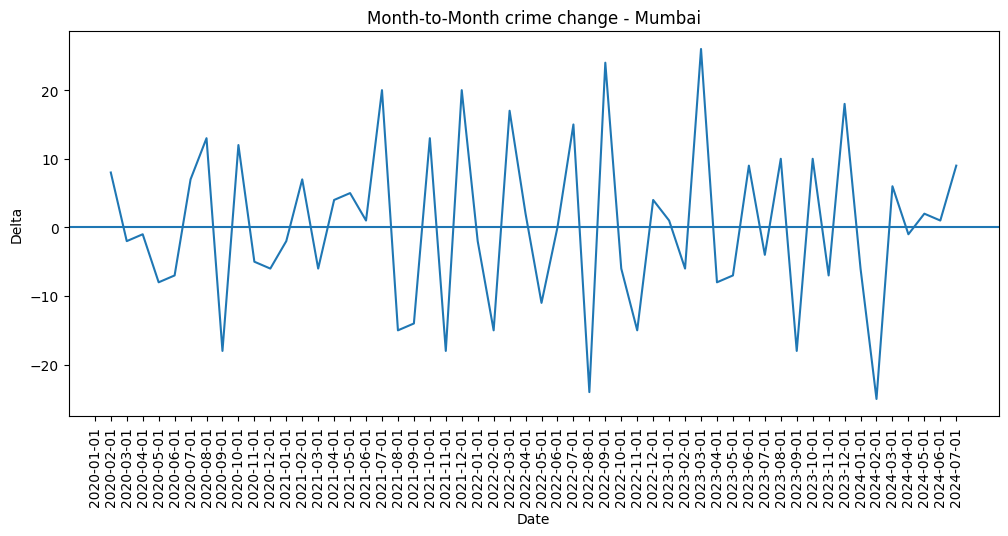

'\nThere seems to be major fluctuations in crime change month after month indicating high volatility\nand unstable crime \n'

In [25]:
#Analyzing month-to-month change in crime count grouped by city

monthly_complete["Delta"] = (
    monthly_complete
    .groupby("City")["Crime_Count"]
    .diff()
)

city = "Mumbai"

city_df = monthly_complete[monthly_complete["City"] == city]

plt.figure(figsize=(12, 5))
plt.plot(city_df["Date"], city_df["Delta"])
plt.title(f"Month-to-Month crime change - {city}")
plt.axhline(0)
plt.xlabel("Date")
plt.ylabel("Delta")
plt.xticks(rotation = 90)
plt.show()

"""
There seems to be major fluctuations in crime change month after month indicating high volatility
and unstable crime 
"""

In [9]:
"""
Calculating the trend slope to show the strength and direction of crime across the entire dataset
using crime count as the independent variable. 
"""
import numpy as np

def compute_trend_slope(city_df):
    y = city_df["Crime_Count"].values
    x = np.arange(len(y))
    if len(y) < 2:
        return np.nan
    slope = np.polyfit(x, y, 1)[0] #Return the highest coefficient (highest crime count by minimizing sum of squared errors)
    return slope

trend_slopes = (
    monthly_complete
    .groupby("City")
    .apply(compute_trend_slope)
    .reset_index(name = "Trend_Slope")
)

monthly_complete = monthly_complete.merge(trend_slopes, on="City", how="left")


C:\Users\abum0\AppData\Local\Temp\ipykernel_16908\82088503.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_trend_slope)


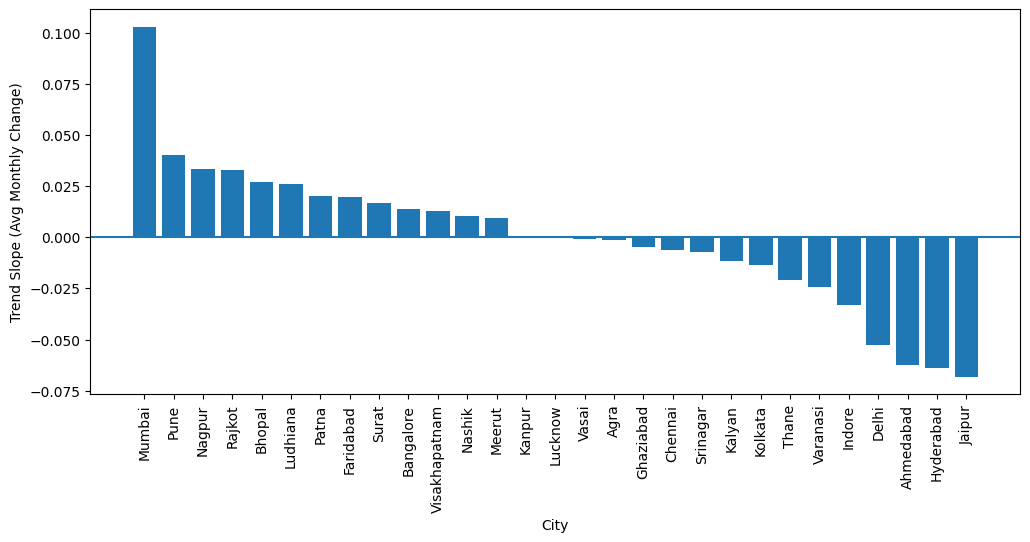

In [30]:
#Plotting a graph using trend slope
#Trend slope shows long-term direction of crime rather than short-term fluctuations
"""
Due to limited historical data, trend slopes show small magnitudes, indicating relatively stable crime 
patterns across cities
"""
trend_df = (
    monthly_complete[["City", "Trend_Slope"]]
    .drop_duplicates()
    .sort_values("Trend_Slope", ascending=False)
)

plt.figure(figsize=(12, 5))
plt.bar(trend_df["City"], trend_df["Trend_Slope"])
plt.axhline(0) #reference line
#plt.title("Crime Trend Slope by City")
plt.xlabel("City")
plt.ylabel("Trend Slope (Avg Monthly Change)")
plt.xticks(rotation = 90)
plt.show()

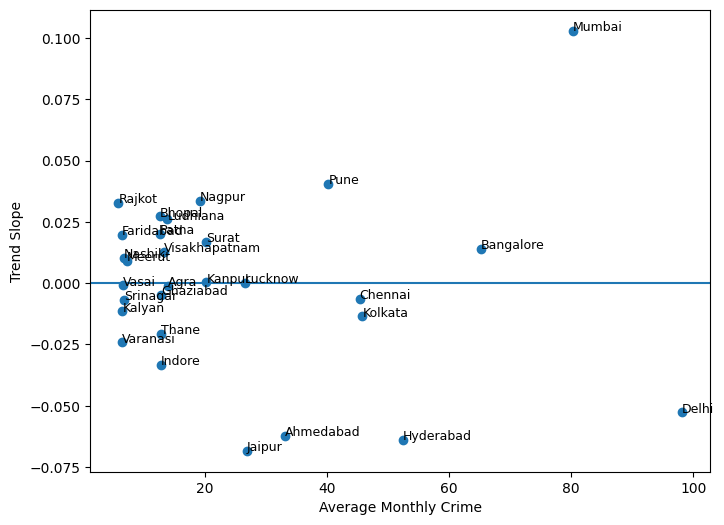

In [31]:
"""
Shows severity vs direction
High Crime + Increasing trend = Dangerous
High Crime + Decreasing trend = Improving
Low Crime + Increasing trend = emerging risk
"""
avg_crime = (
    monthly_complete
    .groupby("City")["Crime_Count"]
    .mean()
    .reset_index(name = "Avg_Crime")
)
trend_plot_df = trend_df.merge(avg_crime, on="City")

plt.figure(figsize = (8, 6))
plt.scatter(trend_plot_df["Avg_Crime"], trend_plot_df["Trend_Slope"])

for _,row in trend_plot_df.iterrows():
    plt.text(row["Avg_Crime"], row["Trend_Slope"], row["City"], fontsize = 9)

plt.axhline(0)
plt.xlabel("Average Monthly Crime")
plt.ylabel("Trend Slope")
#plt.title("Crime Trend Direction vs Crime Level")
plt.show()

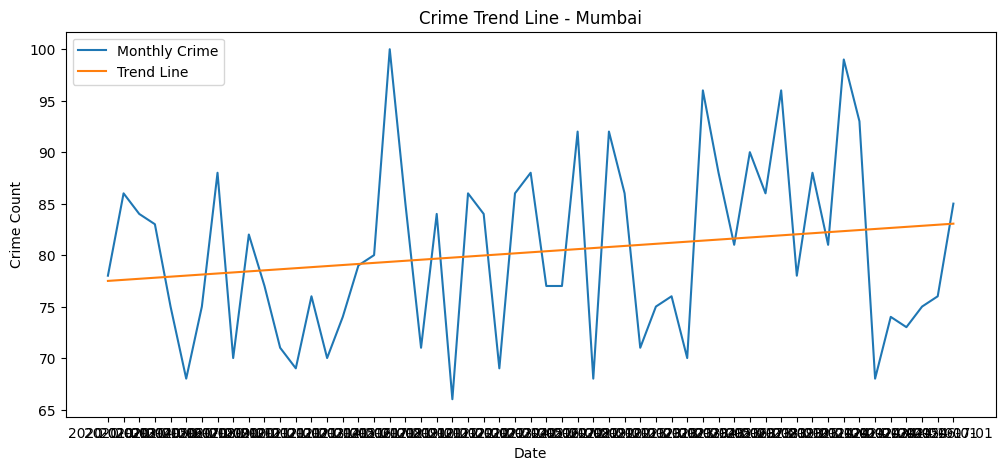

In [12]:
#It helps explain where the slope is coming from
city = "Mumbai"
city_df = monthly_complete[monthly_complete["City"] == city]

x = np.arange(len(city_df))
y = city_df["Crime_Count"].values

slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

plt.figure(figsize=(12, 5))
plt.plot(city_df["Date"], y, label = "Monthly Crime")
plt.plot(city_df["Date"], trend_line, label = "Trend Line")
plt.title(f"Crime Trend Line - {city}")
plt.xlabel("Date")
plt.ylabel("Crime Count")
plt.legend()
plt.show()

In [13]:
monthly_complete.to_csv("monthly_data.csv", index = False)